<img src="https://github.com/nicholasmetherall/digital-earth-pacific-macblue-activities/blob/main/attachments/images/DE_Pacific_banner.JPG?raw=true" width="900"/>

Figure 1.1.a. Jupyter environment + Python notebooks

# Digital Earth Pacific Notebook 1D generate map prediction for your area of interest

The objective of this notebook is to prepare a geomad postcard for your AOI (masking, scaling and loading additional band ratios and spectral indices) and sampling all the datasets into a csv based on your training data geodataframe.

## Step 1.1: Configure the environment

In [2]:
from datetime import datetime
from shapely.geometry import Polygon
from shapely import box
from pyproj import CRS 
import folium
import geopandas as gpd
import numpy as np
import pandas as pd
import rasterio as rio
import xarray as xr
import rioxarray
import joblib
from ipyleaflet import basemaps
import pystac_client
from dask.distributed import Client as DaskClient
from odc.stac import load, configure_s3_access
import planetary_computer
from odc.stac import load
from pystac.client import Client
from pystac_client import Client
STAC_URL = "https://stac.digitalearthpacific.org" 
client = Client.open(STAC_URL)
from skimage.feature import graycomatrix, graycoprops
import matplotlib.pyplot as plt
from matplotlib import colors
from utils import load_data, load_s1_dem, scale, calculate_band_indices, apply_mask, mask_land, all_masks, do_prediction

In [3]:
# Reload scripts and imports
%load_ext autoreload
%autoreload 2

<font color='red'>1.1. Include the name of the site you have been working with in notebooks 1A-1C - area of interest or `aoi`

In [7]:
version = "aoi"

In [8]:
catalog = "https://stac.digitalearthpacific.org"
client = Client.open(catalog)

In [10]:
# 1. Read the file
aoi = gpd.read_file(f"training-data/{version}.geojson")

# 2. Get the bounding box directly from the GeoDataFrame
# This returns exactly what STAC needs: (minx, miny, maxx, maxy)
bbox = aoi.total_bounds 

# 3. Proceed with your search
year = '2025'
items = list(
    client.search(
        collections=["dep_s2_geomad"],
        bbox=bbox,
        datetime=year
    ).items()
)

## Step 1.2: Configure STAC access and search parameters

<font color='red'>1.2. Update the year below within the variable datetime

In [12]:
datetime = "2025"

items = client.search(
    collections=["dep_s2_geomad"],
    datetime=datetime,
    bbox=bbox
).item_collection()

print(f"Found {len(items)} items in for {datetime}")

Found 1 items in for 2025


In [13]:
measurements = ["nir", "red", "blue", "green", "emad", "smad", "bcmad", "green", "nir08", "nir09", "swir16", "swir22", "coastal", "rededge1", "rededge2", "rededge3"]
data = load_data(
    items,
    measurements,
    bbox,
)

<font color='red'>1.3. Print the resulting variable
>print(`variable`)

In [14]:
print(data)

<xarray.Dataset> Size: 4MB
Dimensions:      (y: 300, x: 354, time: 1)
Coordinates:
  * y            (y) float64 2kB -2.041e+06 -2.041e+06 ... -2.044e+06 -2.044e+06
  * x            (x) float64 3kB 3.165e+06 3.165e+06 ... 3.169e+06 3.169e+06
    spatial_ref  int32 4B 3832
  * time         (time) datetime64[ns] 8B 2025-01-01
Data variables: (12/15)
    nir          (time, y, x) uint16 212kB dask.array<chunksize=(1, 300, 354), meta=np.ndarray>
    red          (time, y, x) uint16 212kB dask.array<chunksize=(1, 300, 354), meta=np.ndarray>
    blue         (time, y, x) uint16 212kB dask.array<chunksize=(1, 300, 354), meta=np.ndarray>
    green        (time, y, x) uint16 212kB dask.array<chunksize=(1, 300, 354), meta=np.ndarray>
    emad         (time, y, x) float32 425kB dask.array<chunksize=(1, 300, 354), meta=np.ndarray>
    smad         (time, y, x) float32 425kB dask.array<chunksize=(1, 300, 354), meta=np.ndarray>
    ...           ...
    swir16       (time, y, x) uint16 212kB dask.arr

In [15]:
# dask_client = DaskClient(n_workers=1, threads_per_worker=16, memory_limit='16GB')
# configure_s3_access(cloud_defaults=True, requester_pays=True)

<font color='red'>1.4. Scale your `data` variable 
>scaled = scale(`variable`)

In [16]:
scaled = scale(data)

<font color='red'>1.5. Compute (generate) your `scaled` variable 
>`variable` = `variable`.compute().squeeze()

In [17]:
scaled = scaled.compute().squeeze()

<font color='red'>1.6. Calculate the band indices for your `scaled` variable 
>`variable` = calculate_band_indices(`variable`)


In [18]:
scaled = calculate_band_indices(scaled)

In [19]:
Dataset = scaled

<font color='red'>1.7. Explore the resulting variable `Dataset` 
>`Dataset.odc.explore(vmin = 0, vmax = 0.3, bands = ["red", "green", "blue"], crs="EPSG:3832")`


In [21]:
Dataset.odc.explore(vmin = 0, vmax = 0.3, bands = ["red", "green", "blue"], crs="EPSG:3832")

<font color='red'>1.8. Mask out the `scaled` variable 
> masked_scaled, mask = all_masks(`variable`, return_mask = True)


In [22]:
masked_scaled, mask = all_masks(scaled, return_mask = True)

In [23]:
# To inspect masked scaled dataset
masked_scaled

<xarray.Dataset> Size: 26MB
Dimensions:        (y: 300, x: 354)
Coordinates:
  * y              (y) float64 2kB -2.041e+06 -2.041e+06 ... -2.044e+06
  * x              (x) float64 3kB 3.165e+06 3.165e+06 ... 3.169e+06 3.169e+06
    spatial_ref    int32 4B 3832
    time           datetime64[ns] 8B 2025-01-01
Data variables: (12/32)
    nir            (y, x) float64 850kB nan nan nan nan ... 0.018 0.0181 0.0207
    red            (y, x) float64 850kB nan nan nan nan ... 0.0246 0.0248 0.0272
    blue           (y, x) float64 850kB nan nan nan nan ... 0.0442 0.0444 0.0474
    green          (y, x) float64 850kB nan nan nan nan ... 0.041 0.0413 0.044
    emad           (y, x) float32 425kB nan nan nan ... 0.05309 0.05315 0.06457
    smad           (y, x) float32 425kB nan nan nan ... 3.432e-06 4.834e-06
    ...             ...
    ndci           (y, x) float64 850kB nan nan nan ... -0.02479 -0.009276
    nbi            (y, x) float64 850kB nan nan nan ... -0.08383 -0.07254
    ndmi           (y, x) float64 850kB nan nan nan ... 0.08108 0.08383 0.07254
    bsi            (y, x) float64 850kB nan nan nan ... -0.2329 -0.2327 -0.2161
    awei           (y, x) float64 850kB nan nan nan nan ... 0.1003 0.1011 0.1037
    tc_wetness     (y, x) float64 850kB nan nan nan ... 0.02449 0.02466 0.02561

<font color='red'>1.9. Prepare your satellite data into a stacked array (a table / grid of all the values of data) used in the statistics (machine learning) process: 

In [24]:
# combined_ds = masked_scaled.drop_vars("count")
combined_da = masked_scaled.to_dataarray()
combined_da = combined_da.squeeze()#.stack(dims=["y", "x"])#.transpose()
stacked_arrays_2d = combined_da.stack(new_dim=("y", "x")) 
reordered_data_array = stacked_arrays_2d.transpose('new_dim', 'variable')
stacked_arrays_2d.shape

(32, 106200)

In [25]:
# Replace any infinities with NaN
stacked_arrays_2d = stacked_arrays_2d.where(stacked_arrays_2d != float("inf"))
stacked_arrays_2d = stacked_arrays_2d.where(stacked_arrays_2d != float("-inf"))

# Replace any NaN values with 0
df = stacked_arrays_2d.squeeze().fillna(0).transpose().to_pandas()

# Remove the all-zero rows
zero_mask = (df == 0).all(axis=1)  # Creates a boolean Series
non_zero_df = df.loc[~zero_mask]  # Filters out all-zero rows

# Create a new array to hold the predictions
full_pred = pd.Series(np.nan, index=df.index)

reordered_data_array = stacked_arrays_2d.transpose('new_dim', 'variable')

### Model training

In [26]:
reordered_data_array

<xarray.DataArray (new_dim: 106200, variable: 32)> Size: 27MB
array([[        nan,         nan,         nan, ...,         nan,
                nan,         nan],
       [        nan,         nan,         nan, ...,         nan,
                nan,         nan],
       [        nan,         nan,         nan, ...,         nan,
                nan,         nan],
       ...,
       [ 0.018     ,  0.0246    ,  0.0442    , ..., -0.23290387,
         0.100275  ,  0.02448627],
       [ 0.0181    ,  0.0248    ,  0.0444    , ..., -0.23274162,
         0.101075  ,  0.02465744],
       [ 0.0207    ,  0.0272    ,  0.0474    , ..., -0.21607143,
         0.103675  ,  0.02561373]])
Coordinates:
    spatial_ref  int32 4B 3832
    time         datetime64[ns] 8B 2025-01-01
  * variable     (variable) object 256B 'nir' 'red' ... 'awei' 'tc_wetness'
  * new_dim      (new_dim) object 850kB MultiIndex
  * y            (new_dim) float64 850kB -2.041e+06 -2.041e+06 ... -2.044e+06
  * x            (new_dim) float64 850kB 3.165e+06 3.165e+06 ... 3.169e+06

<font color='red'>2.0. Load the model file you generated in notebook 1C.  
>model = joblib.load("models/`your-model-name`.model")

In [28]:
model = joblib.load("models/nm-lulc-nasese-test.model")

<font color='red'>2.1. Run the following code unchanged to prepare all the data for the prediction / map generation process.  

In [29]:
# Predict the classes
predicted = model.predict(reordered_data_array)

In [30]:
# print("Prediction Input CRS:", reordered_data_array.rio.crs)
print("Prediction Input CRS:", data.rio.crs)

Prediction Input CRS: EPSG:3832


In [31]:
# Reshape back to the original 2D array
reordered_data_array = predicted.reshape(len(masked_scaled.y), len(masked_scaled.x))

# Convert to an xarray again, because it's easier to work with
predicted_da = xr.DataArray(
    reordered_data_array, coords={"y": masked_scaled.y, "x": masked_scaled.x}, dims=["y", "x"]
)

In [32]:
print(predicted_da.dtype)  # Check the dtype of your DataArray
predicted_da = predicted_da.astype('float32')  # Convert to float32

# Check for NaN values
if np.isnan(predicted_da).any():
    print("NaN values found in the data")
    # Handle NaN values, e.g. by filling them
    predicted_da = predicted_da.fillna(-9999)  # Replace NaN with 0 or appropriate value

float32


<font color='red'>2.2. You have prepped a `masked_scaled` satellite image. Generate this using `variable.compute()` below :  
>`variable` = `variable`.compute()

In [33]:
masked_scaled = masked_scaled.compute()

<font color='red'>2.3. Do the prediction :  


In [34]:
predicted = do_prediction(masked_scaled, model)
predicted


<xarray.DataArray (y: 300, x: 354)> Size: 425kB
array([[8., 8., 8., ..., 8., 8., 8.],
       [8., 8., 8., ..., 8., 8., 8.],
       [8., 8., 8., ..., 8., 8., 8.],
       ...,
       [8., 8., 8., ..., 8., 8., 8.],
       [8., 8., 8., ..., 8., 8., 8.],
       [8., 8., 8., ..., 8., 8., 8.]], dtype=float32)
Coordinates:
  * y        (y) float64 2kB -2.041e+06 -2.041e+06 ... -2.044e+06 -2.044e+06
  * x        (x) float64 3kB 3.165e+06 3.165e+06 ... 3.169e+06 3.169e+06

<font color='red'>2.4. Print the results  
>print(`variable`)


In [35]:
print(predicted)

<xarray.DataArray (y: 300, x: 354)> Size: 425kB
array([[8., 8., 8., ..., 8., 8., 8.],
       [8., 8., 8., ..., 8., 8., 8.],
       [8., 8., 8., ..., 8., 8., 8.],
       ...,
       [8., 8., 8., ..., 8., 8., 8.],
       [8., 8., 8., ..., 8., 8., 8.],
       [8., 8., 8., ..., 8., 8., 8.]], dtype=float32)
Coordinates:
  * y        (y) float64 2kB -2.041e+06 -2.041e+06 ... -2.044e+06 -2.044e+06
  * x        (x) float64 3kB 3.165e+06 3.165e+06 ... 3.169e+06 3.169e+06


<font color='red'>2.5. Mask results :  


In [36]:
predicted = predicted.where(mask)
# `prediction` is your predicted class array# `mask` is your boolean mask, where True means masked
nodata_value = -9998  # or -9999, or whatever you chooseprediction_with_mask = prediction.copy()
predicted['mask'] = nodata_value

In [37]:
predicted_filled = predicted.fillna(-9999)
predicted_int = predicted_filled.astype(np.int32)

<font color='red'>2.6. Define your classes and colours :  


In [38]:
from matplotlib import colors

# Updated classes list to include No Data (Code 0)
classes = [
    [0, 'No_Data', '#00000000'], # <-- NEW: Code 0 mapped to a light gray color
    [1, 'Forest_land', '#064a00'],
    [2, 'Grazing_Cropland', '#FFEE8C' ],
    [3, 'Wetland', '#73ffd2'],
    [4, 'Settlements', '#bd0007'],
    [5, 'Bare_land','#919191'],
    [6, 'Water','#71a8ff'],
]


<font color='red'>2.7. Plot the result :  


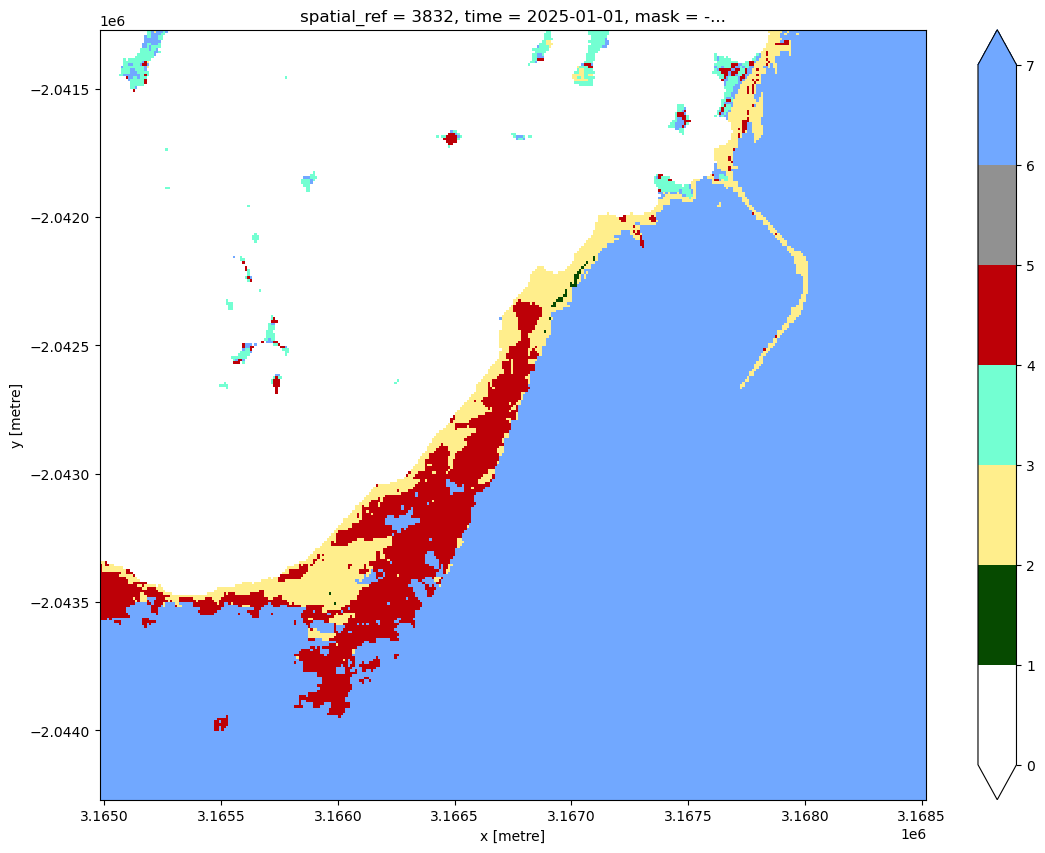

In [39]:
values_list = [c[0] for c in classes]
color_list = [c[2] for c in classes]

# Build a listed colormap.
c_map = colors.ListedColormap(color_list)
bounds = values_list + [7]
norm = colors.BoundaryNorm(bounds, c_map.N)

predicted_int.plot.imshow(cmap=c_map, norm=norm, size=10)

<font color='red'>2.8. Export the final result `predicted_int`:  
>`variable`.odc.write_cog(f"{version}-prediction.tiff")

<font color='red'>2.9. Explore the final result `predicted_int/predicted`:  
> `variable`.odc.explore(cmap=c_map, tiles=basemaps.Esri.WorldImagery)